## Check the Qutip Class: Phase diagram of the Steady states

#### Imports



In [1]:
import numpy as np
import qutip
from qutip import concurrence
from qutip_class import SpinHamiltonian,SteadyStateSolver,SpinOperator,ManyBodyQutipOperator
import matplotlib.pyplot as plt
from typing import List,Tuple

The Qutip library is focused on numerical tools and methods for Open Quantum System. The aim of this notebook is to show how we can envelope Qutip in a Many-Body fashion.

Furthermore, we develop a Steady State Solver Class. 

#### The building block: A ManyBodyQutipOperator

This class initialize a General ManyBody operator without any restriction about the either the representation or the form. 

The class takes as input a list of lists qutip.Qobj (local operators) and a description of the ManyBody operator.
The inner list defines the tensor product, the outer list defines the sum between many-body operators.

In [3]:
xxx=[[qutip.sigmax() for i in range(3)]]


xxx_mbqo=ManyBodyQutipOperator(local_op=xxx,description="x_0 x_1 x_2 operator",verbose=1)

print(xxx_mbqo)

x_0 x_1 x_2 operator 
 Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]] 



The attributes are:

        -) The quitp operator (qutip.Qobj), hidden attribute that contains the qutip representation of the many-body operator;
        -) The description (Optional[str]), a comment or a text that describes the many-body operator;
        -) verbose (int), if 0 the print is just the description string, if 1 is both the description and the qutip representation.

The method is:
        -) expect_value, for a given state $\ket{\Psi}$ (quitp.Qobj) it returns the expectation value of the many-body operator on the given state $\ket{\Psi}$
        

In [4]:
print(xxx_mbqo)

# define psi
# define the full
# spin up state | 1, 1, 1>
# as a qutip object
psi=qutip.basis(2)
psi_2=qutip.tensor(psi,psi)
psi_3=qutip.tensor(psi_2,psi)

print(xxx_mbqo.expect_value(psi=psi_3))

x_0 x_1 x_2 operator 
 Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]] 

0.0


### Spin Operator

Many quantum libraries for many-body systems use compact initialization by means of strings and dictionaries (QuSpin, ITensor, ...). The idea of the subclass Spin Operator is to encode all the information required for initialize a many-body Spin operator (indices, directions, couplings and the number of sites).

Suppose we want to define a coupling operator as

\begin{equation}
V=\sum_{ij} J_{ij} Z_i Z_j,
\end{equation}

with $J_{ij}$ that defines the geometry and the couplings. Suppose that J is given by

\begin{equation}
J=\begin{bmatrix} 0 & 1 & 2 \\
                  1 & 0 & 3 \\
                  2 & 3 & 0 \\ \end{bmatrix},
\end{equation}

in a $l=3$ sites system. The first thing that we construct is the index List:





In [6]:
size=3
index=[('z',1,'z',0),('z',2,'z',0),('z',2,'z',1)]

defined as a tuple of direction (string) and local index. Then we defined the coupling list:

In [7]:
couplings=[1,2,3]

and now we can define the spin operator

In [8]:
jzz=SpinOperator(index=index,coupling=couplings,size=size,verbose=1)

print(jzz)

(couplings, operator) -> 
 ( 1 ,  ('z', 1, 'z', 0) ) 
 ( 2 ,  ('z', 2, 'z', 0) ) 
 ( 3 ,  ('z', 2, 'z', 1) ) 
 
 Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 6.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -4.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -2.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -2.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -4.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  6.]] 



#### Another example of Spin Operator

short range clean ising couplings can be initialized immediately

\begin{equation}
    H=J\sum^{2}_{i=0} X_i X_{i+1} 
\end{equation}


Data

In [11]:
# sites
l=3

# indices
# 1nn coupling term in pbc
idx=[('z',i,'z',(i+1)%l) for i in range(l)] #pbc

# type of coupling
# along the x direction
# the loop is because the
# number of localized operators
# is 3.

# the coupling is J=1
coupling=[1 for i in range(l)]

# define the abstract operator
# as xx_ao
xx_ao=SpinOperator(index=idx,coupling=coupling,size=l,verbose=1)


# the printout method
# gives a description
# of the operator as
# a dictionary in the
# indeces




print(xx_ao)
 

(couplings, operator) -> 
 ( 1 ,  ('z', 0, 'z', 1) ) 
 ( 1 ,  ('z', 1, 'z', 2) ) 
 ( 1 ,  ('z', 2, 'z', 0) ) 
 
 Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 3.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  3.]] 



The spin operator subclass ihnerits all the methods and attributes of the Many-Body Operator

In [12]:
# define the full
# spin up state | 1, 1, 1>
# as a qutip object
psi=qutip.basis(2)
psi_2=qutip.tensor(psi,psi)
psi_3=qutip.tensor(psi_2,psi)

# AO representation
print(xx_ao)
print('\n')

# expt value of Jxx+hz
xx_z=xx_ao.expect_value(psi=psi_3)
print('expect value=',xx_z,'\n')






(couplings, operator) -> 
 ( 1 ,  ('z', 0, 'z', 1) ) 
 ( 1 ,  ('z', 1, 'z', 2) ) 
 ( 1 ,  ('z', 2, 'z', 0) ) 
 
 Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 3.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  3.]] 



expect value= 3.0 



### Many-Body Hamiltonians

Imports

In [1]:
import numpy as np
import qutip
from qutip import concurrence
from qutip_class import SpinHamiltonian,SteadyStateSolver,SpinOperator,ManyBodyQutipOperator,Hamiltonian,FockOperator
import matplotlib.pyplot as plt
from typing import List,Tuple

We consider another subclass of the ManyBodyQutipOperator class, called Hamiltonian. This class takes as input a list of many-body operators divided into couplings (two body interaction), local interactions and other terms (3 body, and so on). 

The difference between all these lists is just in the description, the lists has the same type and can be optionals.

Suppose we want to define the following Hamiltonian

\begin{equation}
H= \mu \sum_i c^{\dag}_i c_i + h\sum_i X_i + g\sum_i Z_i (c^{\dag}_{i+1} + c_{i+1})
\end{equation}

First we define the Fermionic


In [2]:
size=3
index_fock=[('a_dag',i,'a',i) for i in range(size)]
coupling=[1. for i in range(size)]
n=FockOperator(index=index_fock,coupling=coupling,size=size,exc_numb=2) # Fermions


Then the spin part

In [3]:
x=SpinOperator(index=[('x',i) for i in range(size)],coupling=coupling,size=size)


Group them together into the same representation

In [5]:
x_n=ManyBodyQutipOperator([[n.qutip_op,x.qutip_op]],description='free fermions hamiltonian and free spin hamiltonian',verbose=1)

print(x_n)


free fermions hamiltonian and free spin hamiltonian 
 Quantum object: dims = [[2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2]], shape = (64, 64), type = oper, isherm = True
Qobj data =
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 3.]
 [0. 0. 0. ... 0. 0. 3.]
 [0. 0. 0. ... 3. 3. 0.]] 



Finally, the interaction

The interaction is given by a sum of local operators in different representation. For this reason we create a many-body operator from the many-body operators in the different representations

In [12]:
list_ops=[]
for i in range(size):
    s_int=SpinOperator(index=[('z',i)],coupling=[1.],size=size)
    c_dag_c=FockOperator(index=[('a_dag',(i+1)%size),('a',(i+1)%size)],coupling=[1.,1.],size=size,exc_numb=2) #pbc
    list_ops.append([c_dag_c.qutip_op,s_int.qutip_op])
    
int_term=ManyBodyQutipOperator(local_op=list_ops,description='Interaction Hamiltonian',verbose=1)

print(int_term)

Interaction Hamiltonian 
 Quantum object: dims = [[2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2]], shape = (64, 64), type = oper, isherm = True
Qobj data =
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] 



Create the whole Hamiltonian

In [13]:
h0=Hamiltonian(size=size,couplings=[int_term],ext_fields=[x_n])

print(h0)

Hermitian Check positive! well done! 

Coupling Terms: 
Interaction Hamiltonian 
 Quantum object: dims = [[2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2]], shape = (64, 64), type = oper, isherm = True
Qobj data =
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] 
External fields: 
free fermions hamiltonian and free spin hamiltonian 
 Quantum object: dims = [[2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2]], shape = (64, 64), type = oper, isherm = True
Qobj data =
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 3.]
 [0. 0. 0. ... 0. 0. 3.]
 [0. 0. 0. ... 3. 3. 0.]] 
Other terms: 
free fermions hamiltonian and free spin hamiltonian 
 Quantum object: dims = [[2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2]], shape = (64, 64), type = oper, isherm = True
Qobj data =
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 

We want a smart and clear way to define Spin chain Hamiltonians without defining couplings and interactions every time. For this reason we create a subclass of the AbstractOperator called IsingHamiltonian (Actually, even if the attributes and methods are the same of an AbstractOperator, IsingHamiltonian is a set of AbstractOperators, one for each coupling terms and external fields).

The class of Spin Hamiltonians is very large and each Spin Chain can be defined with either simple coupling relations (clean 1nn Ising chain) or very complex (spin glass, long-range interaction Ising chain). The IsingHamiltonian class has different options depending on which kind of Spin Chain you want.

If we want to define a Transverse Ising model with nearest neighbour interaction
\begin{equation}
H=J\sum_i Z_i Z_{i+1} + h \sum_i X_i
\end{equation}

The initialization of the class is simple and intuitive. We need just both the coupling $J$ with the directions ('z','z') and the field $h$ with its direction ('x'), if the boundary conditions are either open or periodic (pbc True or False) and the size of the system

In [14]:
from qutip_class import SpinHamiltonian

size:int=4
j:float=1.
h:float=1.

#s=SpinOperator(index=[('x',i) for i in range(size)],coupling=[1,1,1,1],size=size)

# print(s)

#Hamiltonian(size=size,couplings=[s])





# define the critical transverse ising model 1d
transverse_1nn=SpinHamiltonian(direction_couplings=[('z','z')],field_directions=['x'],coupling_values=[j],field_values=[h],pbc=True,size=size)


print(transverse_1nn)
# # the Qobj instead
# print(transverse_1nn.qutip_op)

Hermitian Check positive! well done! 

Coupling Terms: 
(couplings, operator) -> 
 ( 1.0 ,  ('z', 0, 'z', 1) ) 
 ( 1.0 ,  ('z', 1, 'z', 2) ) 
 ( 1.0 ,  ('z', 2, 'z', 3) ) 
 ( 1.0 ,  ('z', 3, 'z', 0) ) 
 
External fields: 
(couplings, operator) -> 
 ( 1.0 ,  ('x', 0) ) 
 ( 1.0 ,  ('x', 1) ) 
 ( 1.0 ,  ('x', 2) ) 
 ( 1.0 ,  ('x', 3) ) 
 
Other terms: 
(couplings, operator) -> 
 ( 1.0 ,  ('x', 0) ) 
 ( 1.0 ,  ('x', 1) ) 
 ( 1.0 ,  ('x', 2) ) 
 ( 1.0 ,  ('x', 3) ) 
 




Let's see a XY Ising chain with a transverse field
\begin{equation}
H=\sum_i J_1 X_i X_{i+1} + J_2 Y_i Y_{i+1} + h \sum_i Z_i
\end{equation}

In [15]:

# define the critical transverse XY model 1d
xy_1nn=SpinHamiltonian(direction_couplings=[('x','x'),('y','y')],field_directions=['z'],coupling_values=[1.,1.],field_values=[1.],pbc=True,size=size)

# take a look at the Hamiltonian


# the Qobj instead
print(xy_1nn)

Hermitian Check positive! well done! 

Coupling Terms: 
(couplings, operator) -> 
 ( 1.0 ,  ('x', 0, 'x', 1) ) 
 ( 1.0 ,  ('x', 1, 'x', 2) ) 
 ( 1.0 ,  ('x', 2, 'x', 3) ) 
 ( 1.0 ,  ('x', 3, 'x', 0) ) 
 
(couplings, operator) -> 
 ( 1.0 ,  ('y', 0, 'y', 1) ) 
 ( 1.0 ,  ('y', 1, 'y', 2) ) 
 ( 1.0 ,  ('y', 2, 'y', 3) ) 
 ( 1.0 ,  ('y', 3, 'y', 0) ) 
 
External fields: 
(couplings, operator) -> 
 ( 1.0 ,  ('z', 0) ) 
 ( 1.0 ,  ('z', 1) ) 
 ( 1.0 ,  ('z', 2) ) 
 ( 1.0 ,  ('z', 3) ) 
 
Other terms: 
(couplings, operator) -> 
 ( 1.0 ,  ('z', 0) ) 
 ( 1.0 ,  ('z', 1) ) 
 ( 1.0 ,  ('z', 2) ) 
 ( 1.0 ,  ('z', 3) ) 
 




### Find the Steady State

Our aim is to Define a Limbladian with an Hamiltonian and a set of dissipative operators and then find the steady state by exact diagonalization (performed by Qutip). For this reason, we define a simple class called SteadyStateSolver that given a Hamiltonian (AbstractOperator) and a set of dissipative operators (List of Abstract Operator) returns with a method the steady state.

In [16]:
from qutip_class import SteadyStateSolver

# coupling with
# the environment
gamma:float=1.

# operator
dir='-'

# define the dissipative operators
cs:List[SpinOperator]=[]
for i in range(size):
    cs.append(SpinOperator(index=[(dir,i)],coupling=[gamma],size=size))




# let's consider the transverse 
# 1nn Hamiltonian
zz_x_minus=SteadyStateSolver(hamiltonian=transverse_1nn,dissipative_ops=cs)

#compute the steady state
zz_x_minus.get_steady_state(method='svd')



Now, we want to study measures such as the correlations at the centre of the chain or the Negativity in the steady state.

In [17]:
# define the correlation
zz=SpinOperator(index=[('z',int(size/2),'z',int(size/2)+1)],coupling=[1.],size=size)

# print the result
print(zz.expect_value(zz_x_minus.steady_state))

# Negativity
# Simon's method
def negativity(rho,mask):
    x = qutip.partial_transpose(rho,mask)
    return (x.norm() - 1)/2

# 0 and 1 spins 
mask=[1,1,0,0]
print(zz_x_minus.steady_state)

# compute the 
# negativity of 0 and 1
neg=negativity(zz_x_minus.steady_state,mask)
print(neg)

# we can put the negativity measure
# as a method in the SteadyStateSolver
print(zz_x_minus.negativity(indices=[0,1]))


0.03880748936960671
Quantum object: dims = [[2, 2, 2, 2], [2, 2, 2, 2]], shape = (16, 16), type = oper, isherm = True
Qobj data =
[[ 0.0514754 +0.j          0.00120843-0.01286885j  0.00120843-0.01286885j
  -0.00582582-0.01163194j  0.00120843-0.01286885j  0.00085228-0.00458859j
  -0.00582582-0.01163194j -0.00613966-0.00927687j  0.00120843-0.01286885j
  -0.00582582-0.01163194j  0.00085228-0.00458859j -0.00613966-0.00927687j
  -0.00582582-0.01163194j -0.00613966-0.00927687j -0.00613966-0.00927687j
  -0.01558217-0.01589485j]
 [ 0.00120843+0.01286885j  0.05295096+0.j          0.00240318+0.j
   0.00506054-0.01358598j  0.00302235+0.j         -0.00140361-0.01254126j
   0.00455801-0.00129717j -0.00224759-0.01456354j  0.00240318+0.j
   0.00506054-0.01358598j -0.00179074+0.00021192j  0.00015254-0.00188249j
   0.00455801-0.00129717j -0.00224759-0.01456354j  0.00183652-0.00185855j
  -0.00216594-0.01317242j]
 [ 0.00120843+0.01286885j  0.00240318+0.j          0.05295096+0.j
   0.00506054-0.01358598j 

## Phase Diagram or Scan of a control parameter in a Clean 1nn Transverse Ising Chain

#### Imports

In [18]:
from qutip_class import SpinOperator,SpinHamiltonian,SteadyStateSolver
import numpy as np
import qutip
from tqdm.notebook import tqdm
from typing import Dict,List,Tuple

#### Hyperparameters

In [19]:
size:int=4
pbc:bool=False
j:float=1.
h_grid:np.ndarray=np.linspace(0.1,5,100)
coupling_noise_grid:float=1.
dir_coupling:Tuple[str]=('x','x')
dir_field:str='z'
dir_noise:str='-'

method='svd'
# method='iterative-lgmres'
# method='direct'

# define the noise operators
cs:List[SpinOperator]=[]
for i in range(size):
    cs.append(SpinOperator(index=[(dir_noise,i)],coupling=[coupling_noise],size=size))


Define the correlation operators that we want to measure

In [20]:
zz=SpinOperator(index=[('z',int(size/2),'z',int(size/2)+1)],coupling=[1.],size=size)
xx=SpinOperator(index=[('x',int(size/2),'x',int(size/2)+1)],coupling=[1.],size=size)

Loop

In [ ]:
neg01=[]
neg02=[]
neg12=[]
xx_vs_h=[]
zz_vs_h=[]
purity=[]

tqdm_iterator=tqdm(h_grid)

for h in tqdm_iterator:
    zz_x=SpinHamiltonian(direction_couplings=[dir_coupling],field_directions=[dir_field],pbc=pbc,size=size,coupling_values=[j],field_values=[h])
    zz_x_minus=SteadyStateSolver(hamiltonian=zz_x,dissipative_ops=cs)
    zz_x_minus.get_steady_state(method=method)
    # compute the negativity
    neg01.append(zz_x_minus.negativity([0,1]))
    neg02.append(zz_x_minus.negativity([0,2]))
    neg12.append(zz_x_minus.negativity([1,2]))
    
    # compute the correlations
    xx_vs_h.append(xx.expect_value(zz_x_minus.steady_state))
    zz_vs_h.append(zz.expect_value(zz_x_minus.steady_state))
    
    #purity
    purity.append(zz_x_minus.purity())

#### Plots

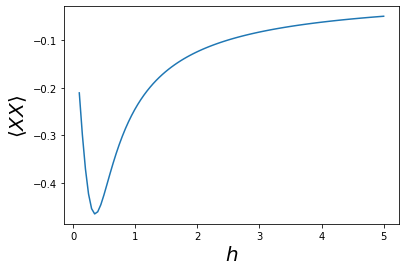

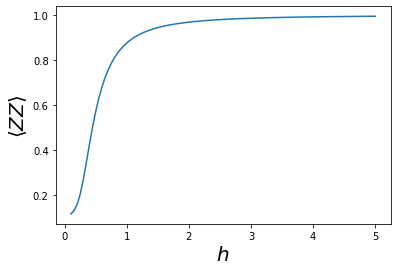

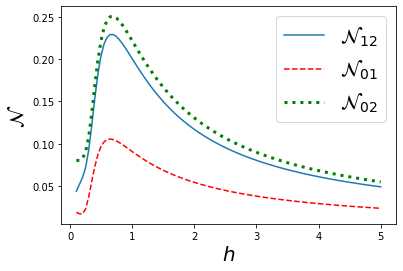

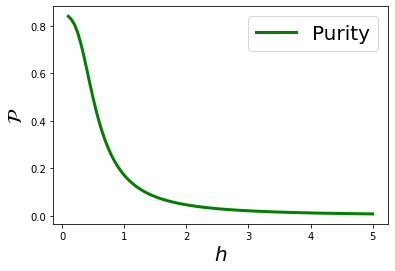

In [22]:
import matplotlib.pyplot as plt

plt.plot(h_grid[0:len(xx_vs_h)],xx_vs_h)
plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\langle XX\rangle$',fontsize=20)
plt.show()

plt.plot(h_grid[0:len(xx_vs_h)],zz_vs_h)
plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\langle ZZ\rangle$',fontsize=20)
plt.show()

plt.plot(h_grid[0:len(xx_vs_h)],neg12,label=r'$\mathcal{N}_{12}$')
plt.plot(h_grid[0:len(xx_vs_h)],neg01,label=r'$\mathcal{N}_{01}$',linestyle='--',color='red')
plt.plot(h_grid[0:len(xx_vs_h)],neg02,label=r'$\mathcal{N}_{02}$',linestyle=':',linewidth=3,color='green')

plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\mathcal{N}$',fontsize=20)
plt.legend(fontsize=20)
plt.show()

plt.plot(h_grid[0:len(xx_vs_h)],purity,label=r'Purity',linewidth=3,color='green')
plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\mathcal{P}$',fontsize=20)
plt.legend(fontsize=20)
plt.show()

## Phase Diagram or Scan of the environment coupling constant in a Clean 1nn Transverse Ising Chain

#### Imports

In [17]:
from qutip_class import SpinOperator,SpinHamiltonian,SteadyStateSolver
import numpy as np
import qutip
from tqdm import tqdm
from typing import Dict,List,Tuple

#### Hyperparameters

In [18]:
size:int=4
pbc:bool=False
j:float=1.
h:float=1.
coupling_noise_grid:np.ndarray=np.linspace(0.05,10.,100)
dir_coupling:Tuple[str]=('x','x')
dir_field:str='z'
dir_noise:str='-'

method='svd'
# method='iterative-lgmres'
# method='direct'




Define the correlation operators that we want to measure

In [19]:
zz=SpinOperator(index=[('z',int(size/2),'z',int(size/2)+1)],coupling=[1.],size=size)
xx=SpinOperator(index=[('x',int(size/2),'x',int(size/2)+1)],coupling=[1.],size=size)

Loop

In [20]:
neg01=[]
neg02=[]
neg12=[]
xx_vs_h=[]
zz_vs_h=[]
purity=[]

tqdm_iterator=tqdm(coupling_noise_grid)

for coupling_noise in tqdm_iterator:
    
    # define the noise operators
    cs:List[SpinOperator]=[]
    for i in range(size):
        cs.append(SpinOperator(index=[(dir_noise,i)],coupling=[coupling_noise],size=size))
    zz_x=SpinHamiltonian(direction_couplings=[dir_coupling],field_directions=[dir_field],pbc=pbc,size=size,coupling_values=[j],field_values=[h])
    zz_x_minus=SteadyStateSolver(hamiltonian=zz_x,dissipative_ops=cs)
    zz_x_minus.get_steady_state(method=method)
    # compute the negativity
    neg01.append(zz_x_minus.negativity([0,1]))
    neg02.append(zz_x_minus.negativity([0,2]))
    neg12.append(zz_x_minus.negativity([1,2]))
    
    # compute the correlations
    xx_vs_h.append(xx.expect_value(zz_x_minus.steady_state))
    zz_vs_h.append(zz.expect_value(zz_x_minus.steady_state))
    
    #purity
    purity.append(zz_x_minus.purity())

  0%|          | 0/100 [00:00<?, ?it/s]

Hermitian Check positive! well done! 



  1%|          | 1/100 [00:01<02:19,  1.41s/it]

Hermitian Check positive! well done! 



  2%|▏         | 2/100 [00:03<02:59,  1.83s/it]

...

 98%|█████████▊| 98/100 [03:19<00:02,  1.18s/it]

Hermitian Check positive! well done! 



 99%|█████████▉| 99/100 [03:21<00:01,  1.36s/it]

Hermitian Check positive! well done! 



100%|██████████| 100/100 [03:23<00:00,  2.04s/it]


#### Plots

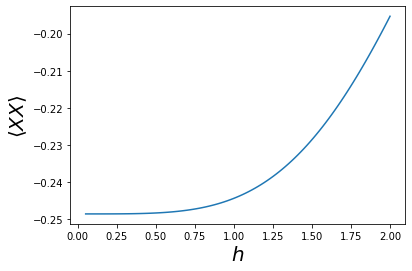

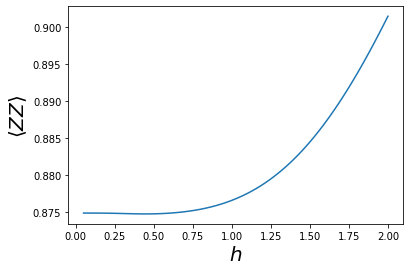

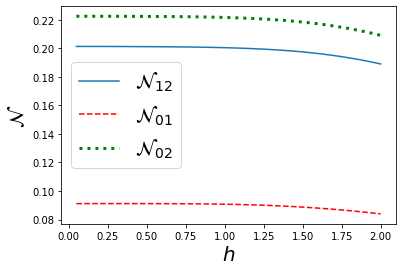

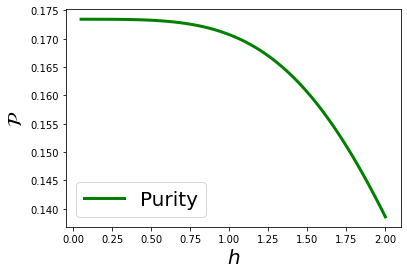

In [16]:
import matplotlib.pyplot as plt

plt.plot(coupling_noise_grid[0:len(xx_vs_h)],xx_vs_h)
plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\langle XX\rangle$',fontsize=20)
plt.show()

plt.plot(coupling_noise_grid[0:len(xx_vs_h)],zz_vs_h)
plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\langle ZZ\rangle$',fontsize=20)
plt.show()

plt.plot(coupling_noise_grid[0:len(xx_vs_h)],neg12,label=r'$\mathcal{N}_{12}$')
plt.plot(coupling_noise_grid[0:len(xx_vs_h)],neg01,label=r'$\mathcal{N}_{01}$',linestyle='--',color='red')
plt.plot(coupling_noise_grid[0:len(xx_vs_h)],neg02,label=r'$\mathcal{N}_{02}$',linestyle=':',linewidth=3,color='green')

plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\mathcal{N}$',fontsize=20)
plt.legend(fontsize=20)
plt.show()

plt.plot(coupling_noise_grid[0:len(xx_vs_h)],purity,label=r'Purity',linewidth=3,color='green')
plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\mathcal{P}$',fontsize=20)
plt.legend(fontsize=20)
plt.show()